# The per-speaker error map — committees corpus, v2

**Toward Personalized Hebrew ASR** · Dolev Abudi, Hadas Yonat

Stage 1: does the Hebrew fine-tune serve every speaker equally, who gains least from it, and what predicts that?

| | model | hypotheses |
|---|---|---|
| **A** | `openai/whisper-large-v3`, language forced to Hebrew | `knesset-asr/knesset-committees-inference`, `hypothesis_A` |
| **B** | `ivrit-ai/whisper-large-v3-turbo-ct2` (Hebrew fine-tune) | same, `hypothesis_B` |

A condensed version of `committees_error_map.ipynb`, kept to what the research uses.

Data: one hour per MK, 65,990 chunks of ≤ 30 s, 267 speakers, 230 h. The functions live in
`src/evaluation/error_map.py` and `error_analysis.py`; `python src/evaluation/error_map.py --run` writes the output tables.

---
## 1. Load, score, filter

Each chunk is scored once (Stage 1 Hebrew normalisation, word-level substitutions/deletions/insertions).
Every WER below is pooled: Σ errors / Σ reference words. Chunks with alignment quality < 0.7 are dropped:
their reference does not match the audio, and both models score WER ≈ 1 on them.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sys.path.insert(0, os.path.join('..', 'src', 'evaluation'))
import error_map as E, error_analysis as X

C_A, C_B, C_GAIN = '#0072B2', '#D55E00', '#009E73'      # model A blue, B orange, gain green
FIG = os.path.join('..', 'docs', 'figures', 'committees_error_map_v2'); os.makedirs(FIG, exist_ok=True)
def save(name): plt.savefig(os.path.join(FIG, name + '.png'), dpi=130, bbox_inches='tight')
pd.set_option('display.width', 160)

seg = E.count_errors(E.load_chunks())
print(f'{len(seg):,} chunks, {seg.speaker_id.nunique()} speakers, {seg.duration_s.sum()/3600:.1f} h')
display(E.by_bucket(seg, 'quality', [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]).round(3))
kept, dropped, effect = E.qc(seg)
effect.round(4)

C:\Users\hadas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


65,990 chunks, 267 speakers, 230.1 h


,chunks,hours,WER_A,WER_B
quality,,,,
"(0.499, 0.6]",3194.0,4.823,1.061,1.014
"(0.6, 0.7]",4619.0,7.955,0.949,0.869
"(0.7, 0.8]",7041.0,15.044,0.776,0.688
"(0.8, 0.9]",11693.0,33.154,0.596,0.490
"(0.9, 1.0]",39443.0,169.116,0.316,0.224


,chunks,hours,ref_words,WER_A,WER_B,CER_A,CER_B
before filter,65990,230.0913,1610207,0.4173,0.3243,0.2662,0.2286
after filter,58180,217.3158,1528937,0.3868,0.2924,0.2414,0.2031
the dropped chunks,7810,12.7755,81270,0.9915,0.9242,0.7527,0.7297


---
## 2. Overall

In [2]:
for tag, name in [('A', 'A  general'), ('B', 'B  Hebrew fine-tune')]:
    e = kept[f'werr_{tag}'].sum()
    print(f'{name:<20} WER {e/kept.n_words.sum():.4f}   CER {kept[f"cerr_{tag}"].sum()/kept.n_chars.sum():.4f}   '
          f'errors: S {kept[f"S_{tag}"].sum()/e:.0%}  D {kept[f"D_{tag}"].sum()/e:.0%}  I {kept[f"I_{tag}"].sum()/e:.0%}')

A  general           WER 0.3868   CER 0.2414   errors: S 49%  D 13%  I 38%
B  Hebrew fine-tune  WER 0.2924   CER 0.2031   errors: S 36%  D 11%  I 53%


B removes about a quarter of A's errors. Over half of B's errors are insertions, words the protocol did not
write down (§8).

---
## 3. Performance per speaker

Per-speaker WER with a 95% bootstrap CI (the speaker's chunks resampled 1,000 times). Spread across speakers
is reported absolutely (SD) and relative to the level (CV = SD / mean), the second being the fair test of
whether the better model is also more *consistent*.

In [3]:
spk = E.per_speaker(kept, n_boot=1000)
r = spk[spk.reliable]
print(f'{len(spk)} speakers, {len(r)} with >= {E.MIN_SEG} chunks (the reliable set used from here on)\n')
pd.DataFrame({t: dict(mean=r[f'wer_{t}'].mean(), median=r[f'wer_{t}'].median(), SD=r[f'wer_{t}'].std(),
                      CV=r[f'wer_{t}'].std() / r[f'wer_{t}'].mean(), p10=r[f'wer_{t}'].quantile(.1), p90=r[f'wer_{t}'].quantile(.9))
              for t in 'AB'}).T.round(3)

267 speakers, 261 with >= 20 chunks (the reliable set used from here on)



,mean,median,SD,CV,p10,p90
A,0.397,0.378,0.099,0.251,0.297,0.505
B,0.295,0.292,0.069,0.233,0.215,0.376


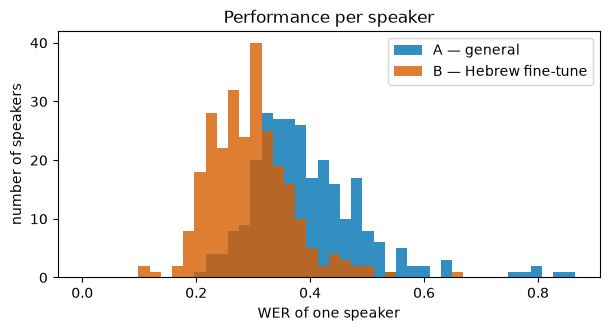

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(0, spk.wer_A.max(), 45)
ax.hist(spk.wer_A, bins=bins, color=C_A, alpha=0.8, label='A — general')
ax.hist(spk.wer_B, bins=bins, color=C_B, alpha=0.8, label='B — Hebrew fine-tune')
ax.set_xlabel('WER of one speaker'); ax.set_ylabel('number of speakers')
ax.set_title('Performance per speaker'); ax.legend(); save('per_speaker_hist'); plt.show()

**Reading it.** B is better for the typical speaker (median 0.378 → 0.292), and the spread shrinks in absolute
terms (SD 0.099 → 0.069) but hardly relative to the level (CV 0.25 → 0.23). The fine-tune makes everyone better,
not everyone equal: under B the 90th-percentile speaker still has 1.75× the WER of the 10th (A: 1.70×).

---
## 4. Adaptation gain per speaker

`gain_abs` = WER_A − WER_B (WER points recovered); `gain_rel` = gain_abs / WER_A (fraction of A's error removed).

In [5]:
print(f'helped: {(r.gain_abs > 0).sum()} / {len(r)};  gain CI above zero: {(r.gain_abs_lo > 0).sum()} / {len(r)}')
print(f'rank correlation  WER_A vs WER_B: {stats.spearmanr(r.wer_A, r.wer_B).statistic:+.2f}   '
      f'WER_A vs gain_abs: {stats.spearmanr(r.wer_A, r.gain_abs).statistic:+.2f}   '
      f'WER_A vs gain_rel: {stats.spearmanr(r.wer_A, r.gain_rel).statistic:+.2f}')
r[['gain_abs', 'gain_rel']].describe().round(3)

helped: 261 / 261;  gain CI above zero: 261 / 261
rank correlation  WER_A vs WER_B: +0.90   WER_A vs gain_abs: +0.64   WER_A vs gain_rel: +0.09


,gain_abs,gain_rel
count,261.000,261.000
mean,0.102,0.252
std,0.053,0.078
min,0.035,0.106
25%,0.074,0.202
50%,0.090,0.244
75%,0.111,0.286
max,0.435,0.578


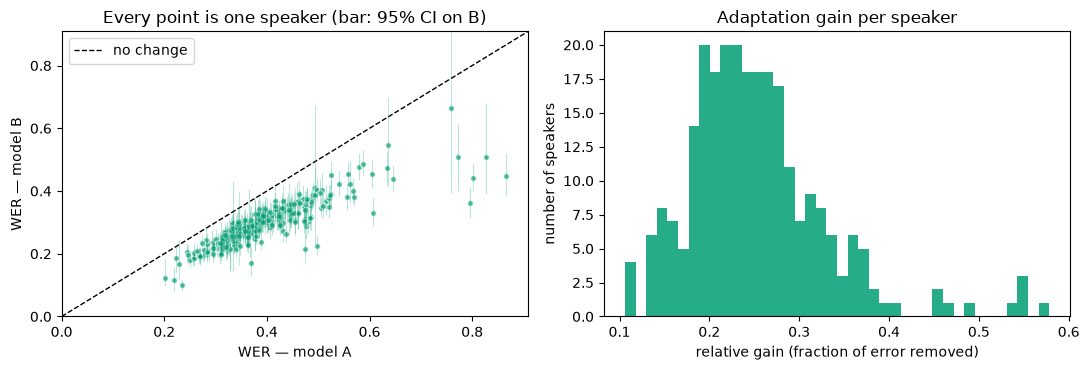

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]; lim = [0, spk.wer_A.max() * 1.05]
ax.plot(lim, lim, 'k--', lw=1, label='no change')
ax.errorbar(spk.wer_A, spk.wer_B, yerr=[spk.wer_B - spk.wer_B_lo, spk.wer_B_hi - spk.wer_B], fmt='none', ecolor=C_GAIN, alpha=0.25, lw=0.8)
ax.scatter(spk.wer_A, spk.wer_B, s=18, color=C_GAIN, alpha=0.7, edgecolor='white')
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_xlabel('WER — model A'); ax.set_ylabel('WER — model B')
ax.set_title('Every point is one speaker (bar: 95% CI on B)'); ax.legend()
ax = axes[1]
ax.hist(r.gain_rel, bins=40, color=C_GAIN, alpha=0.85)
ax.set_xlabel('relative gain (fraction of error removed)'); ax.set_ylabel('number of speakers'); ax.set_title('Adaptation gain per speaker')
plt.tight_layout(); save('gain'); plt.show()

**Reading it.** Every reliable speaker is helped, all 261 beyond noise. Who is hard does not change (rank
correlation 0.90). Hard speakers gain more WER points, but only because they had more errors: the *fraction*
removed is unrelated to difficulty (+0.09), about a quarter for most speakers (IQR 20–29%). It still ranges from
11% to 58%, and §5 shows that range is real.

---
## 5. Is the ranking real?

**Reliability.** Each speaker's sessions are split into odd and even halves; the measure is computed on each,
correlated across speakers and corrected to full length (Spearman-Brown). Near 1: the spread between speakers is
a property of the speakers. Near 0: sampling noise.

,split_half_rho,reliability,speakers
wer_A,0.743,0.852,254
wer_B,0.638,0.779,254
gain_abs,0.747,0.855,254
gain_rel,0.603,0.753,254


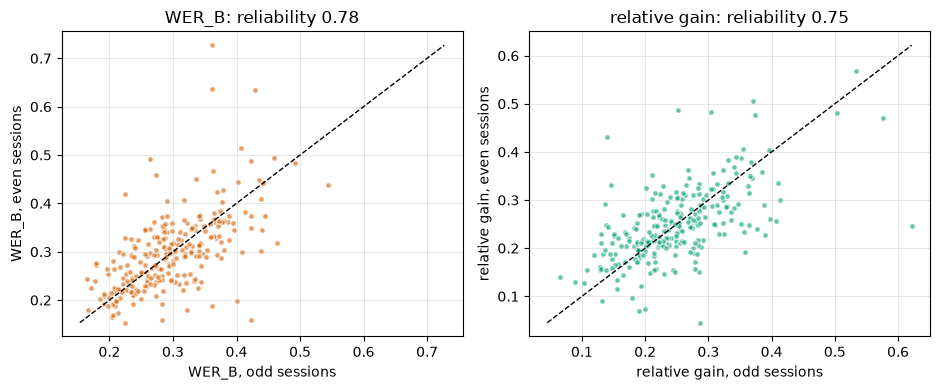

In [7]:
rel, H = X.split_half(kept); display(rel.round(3))
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, m, c, name in [(axes[0], 'wer_B', C_B, 'WER_B'), (axes[1], 'gain_rel', C_GAIN, 'relative gain')]:
    ax.scatter(H[f'{m}_1'], H[f'{m}_2'], s=16, color=c, alpha=0.6, edgecolor='white')
    lim = [min(H[f'{m}_1'].min(), H[f'{m}_2'].min()), max(H[f'{m}_1'].max(), H[f'{m}_2'].max())]
    ax.plot(lim, lim, 'k--', lw=1); ax.set_xlabel(f'{name}, odd sessions'); ax.set_ylabel(f'{name}, even sessions')
    ax.set_title(f'{name}: reliability {rel.loc[m, "reliability"]:.2f}'); ax.grid(alpha=0.3)
plt.tight_layout(); save('reliability'); plt.show()

**A confound.** How much speech a speaker has in the corpus does not predict their WER. The share of their
chunks the quality filter removed does: speakers whose speech aligns badly are also harder to recognise, which
can be acoustics (cross-talk) or a wrong speaker label. The audio gate in `speaker_index/validate_audio.py`
would tell them apart; it has not run.

In [8]:
attrs = E.speaker_attrs(kept)
totals = kept.groupby('speaker_id').agg(werr_A_total=('werr_A', 'sum'), werr_B_total=('werr_B', 'sum'))
G = spk.join(totals).join(attrs)
G['qc_dropped'] = 1 - kept.groupby('speaker_id').size() / seg.groupby('speaker_id').size()
for col, name in [('hours_corpus', 'corpus hours'), ('qc_dropped', 'share removed by the filter')]:
    print(f'{name:<28}' + '   '.join(f'vs WER_{t}: rho {stats.spearmanr(G[col], G[f"wer_{t}"]).statistic:+.2f} '
                                      f'(p {stats.spearmanr(G[col], G[f"wer_{t}"]).pvalue:.1g})' for t in 'AB'))

corpus hours                vs WER_A: rho -0.07 (p 0.3)   vs WER_B: rho +0.06 (p 0.4)
share removed by the filter vs WER_A: rho +0.61 (p 6e-29)   vs WER_B: rho +0.68 (p 5e-37)


**Reading it.** Reliability is 0.75–0.85 for both WER and gain: differences between speakers are stable
properties of the speakers, so ranking them for adaptation is meaningful. Corpus hours predict nothing. The
filter's share predicts WER (rho 0.6–0.7): before spending GPU time on a hard speaker, check their labels.

---
## 6. What predicts difficulty and gain?

Seven ways to group speakers: gender, nationality, religion, religious orientation, country of origin, age
quartile, speaking-rate tertile. For each, **eta²** is the share of between-speaker variance that lies between
the groups, compared with a permutation null (labels shuffled 2,000 times; `null95` is the bar to clear).
Reliable speakers only; groups of ≥ 3; missing metadata excluded.

In [9]:
rank = E.rank_rules(G, n_perm=2000)
rank.round(4)

,groups,speakers,eta2_gain_rel,null95_gain_rel,p_gain_rel,eta2_wer_B,null95_wer_B,p_wer_B,separates_gain,separates_wer
rule,,,,,,,,,,
speaking rate tertile,3,261,0.0916,0.0222,0.0000,0.0008,0.0233,0.9010,True,False
religion,4,258,0.0723,0.0315,0.0020,0.0088,0.0307,0.5055,True,False
nationality,4,258,0.0705,0.0316,0.0025,0.0092,0.0290,0.4830,True,False
age quartile,4,258,0.0499,0.0294,0.0035,0.0088,0.0302,0.5325,True,False
country of origin,6,258,0.0368,0.0439,0.0930,0.0347,0.0438,0.1125,False,False
gender,2,261,0.0196,0.0142,0.0245,0.0267,0.0153,0.0075,True,True
religious orientation,3,187,0.0015,0.0332,0.8765,0.0621,0.0323,0.0020,False,True


The groups themselves: pooled WER_B and relative gain per group, and whether the group could train a shared
fine-tune for Stage 2 (`viable`: ≥ 3 speakers and ≥ 5 h of corpus speech with its largest speaker held out).

In [10]:
groups = pd.concat({name: E.subgroup_table(G, col) for name, col in E.RULES.items()}, names=['rule', 'group'])
groups[['speakers', 'hours_minus_largest', 'wer_B', 'gain_rel', 'viable']].round({'hours_minus_largest': 0, 'wer_B': 3, 'gain_rel': 3})

speakers  hours_minus_largest  wer_B  gain_rel  viable
rule                  group                                                                    
gender                Male                    185               2276.0  0.300     0.250    True
                      Female                   82                865.0  0.276     0.231    True
nationality           Jewish                  229               2918.0  0.295     0.237    True
                      Arab                     22                159.0  0.283     0.294    True
                      Bedouin                   5                 16.0  0.267     0.303    True
                      Druze                     8                 21.0  0.264     0.288    True
                      Unknown                   3                  0.0  0.253     0.239   False
religion              Jewish                  229               2918.0  0.295     0.237    True
                      Muslim                   24                151.0  0.282     0.298    True
                      Christian                 3                  8.0  0.268     0.278    True
                      Druze                     8                 21.0  0.264     0.288    True
                      Unknown                   3                  0.0  0.253     0.239   False
religious orientation Haredi                   27                332.0  0.334     0.234    True
                      Religious                46                685.0  0.293     0.238    True
                      Unrecorded               74                636.0  0.290     0.254   False
                      Secular                 119               1241.0  0.285     0.242    True
                      Sunni                     1                  0.0  0.224     0.358   False
country of origin     Ethiopia                  5                 22.0  0.335     0.273    True
                      MENA                      7                 91.0  0.326     0.283    True
                      Europe                    5                 14.0  0.318     0.237    True
                      FSU                      17                154.0  0.305     0.283    True
                      Americas                  9                 78.0  0.299     0.232    True
                      Israel                  221               2535.0  0.289     0.239    True
                      Unknown                   3                  0.0  0.253     0.239   False
age quartile          age Q4 (oldest)          66                621.0  0.301     0.270    True
                      age Q3                   66                707.0  0.297     0.241    True
                      age Q1 (youngest)        66                720.0  0.288     0.225    True
                      age Q2                   66                722.0  0.287     0.245    True
speaking rate tertile fast speech              89                993.0  0.296     0.221    True
                      medium speech            89                968.0  0.290     0.244    True
                      slow speech              89                928.0  0.290     0.273    True

**The groups, speaker by speaker.** One dot per reliable speaker, coloured by group; bar = group median, line = IQR, dashed = overall median. Left: relative gain; right: absolute gain.

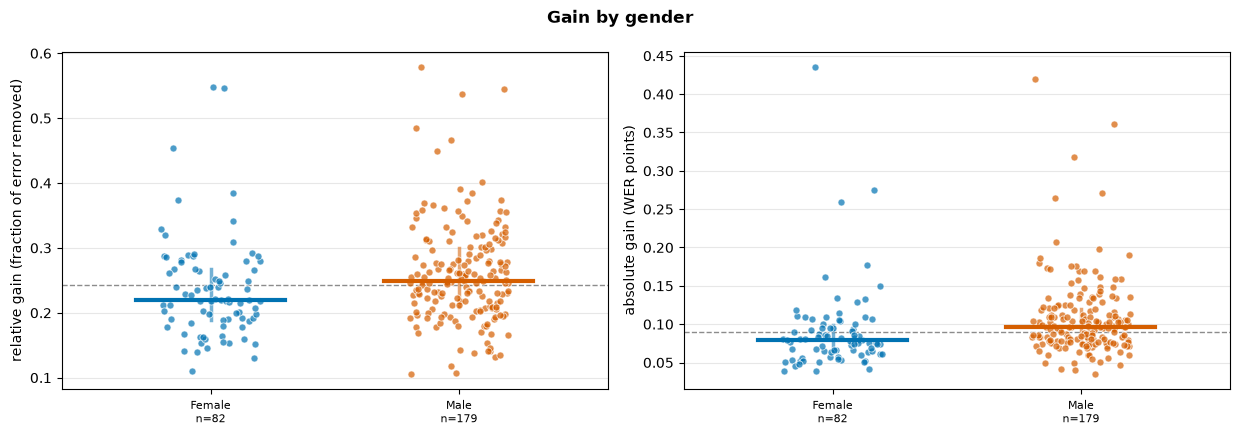

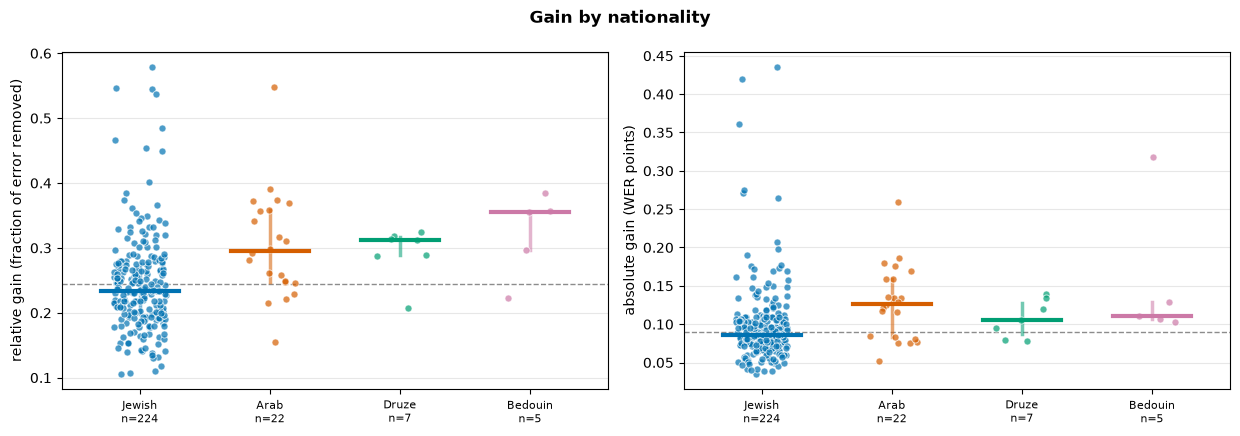

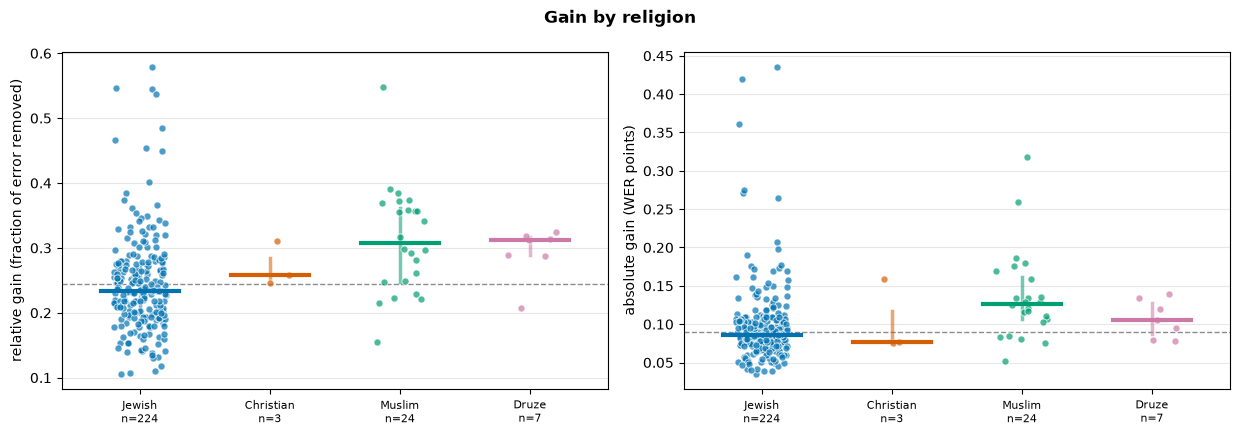

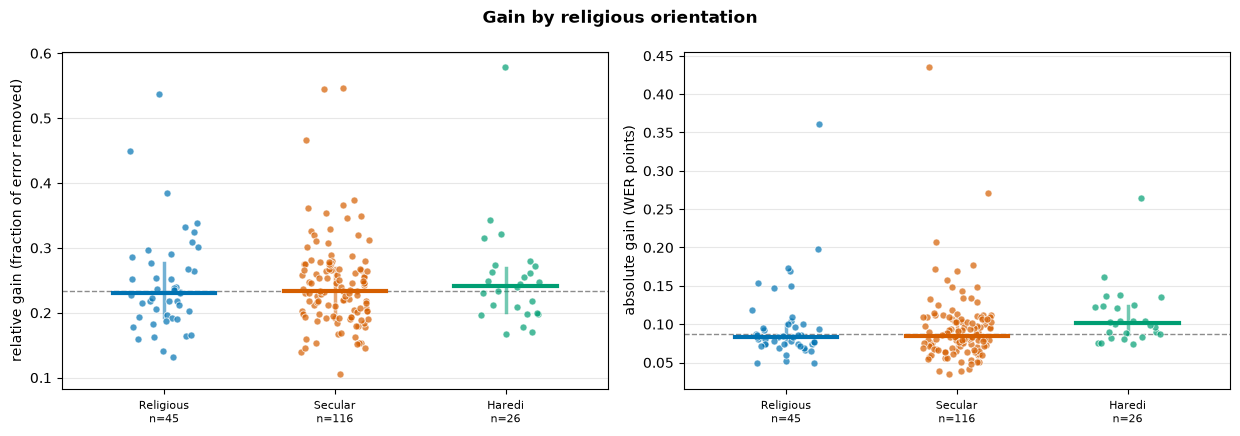

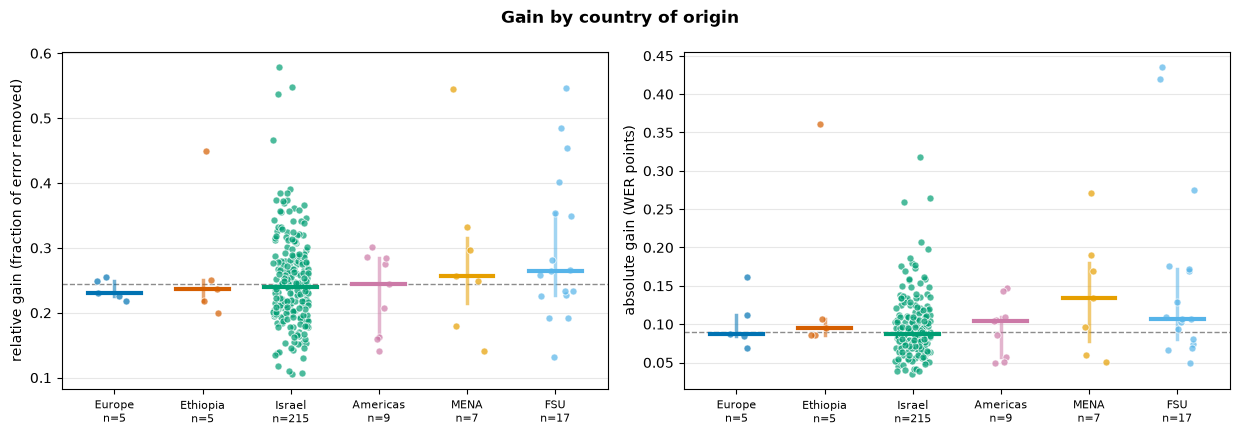

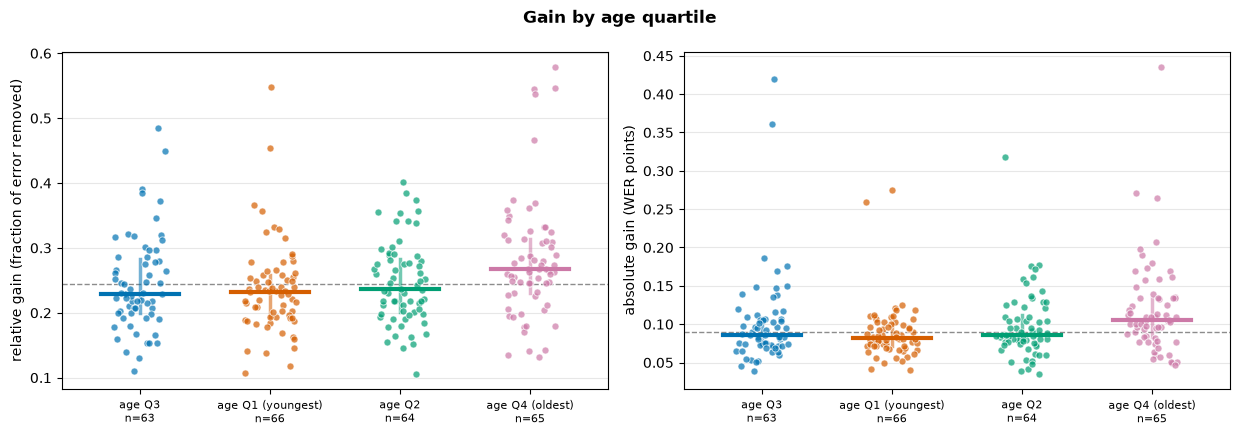

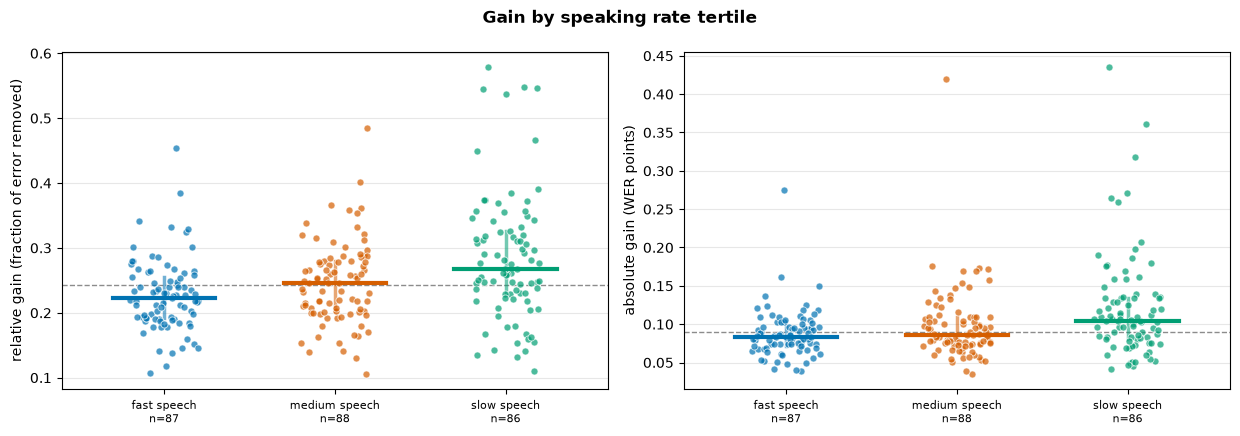

In [11]:
PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#8B4513', '#555555']
def group_plot(name, col):
    d = E.separation_set(G, col)
    order = d.groupby(col, observed=True).gain_rel.median().sort_values().index.tolist()[:len(PALETTE)]
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4)); rng = np.random.default_rng(0)
    for ax, ycol, ylab in [(axes[0], 'gain_rel', 'relative gain (fraction of error removed)'), (axes[1], 'gain_abs', 'absolute gain (WER points)')]:
        ax.axhline(d[ycol].median(), color='0.55', ls='--', lw=1, zorder=1)
        for k, g in enumerate(order):
            v = d.loc[d[col] == g, ycol].dropna().values
            if not len(v): continue
            ax.scatter(k + rng.uniform(-0.2, 0.2, len(v)), v, s=26, color=PALETTE[k], alpha=0.7, edgecolor='white', linewidth=0.7, zorder=3)
            q1, med, q3 = np.percentile(v, [25, 50, 75])
            ax.plot([k, k], [q1, q3], color=PALETTE[k], lw=2.5, alpha=0.55, zorder=2); ax.plot([k - 0.3, k + 0.3], [med, med], color=PALETTE[k], lw=3, zorder=4)
        ax.set_xticks(range(len(order))); ax.set_xticklabels([f'{g}\nn={(d[col] == g).sum()}' for g in order], fontsize=8)
        ax.set_ylabel(ylab); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True); ax.set_xlim(-0.6, len(order) - 0.4)
    fig.suptitle(f'Gain by {name}', fontsize=12, fontweight='bold'); plt.tight_layout(); save('group_' + col); plt.show()

for name, col in E.RULES.items():
    group_plot(name, col)

**Reading it.**

* **Who gains:** speaking rate is the strongest rule (eta² 0.09): slow speakers gain most (27% of A's error
  removed, fast 22%). Religion and nationality are largely the same split: Arab, Muslim, Druze and Bedouin
  speakers gain 29–30% against 24% for Jewish speakers, with no difference in WER_B. The fine-tune closes a
  gap the general model had on them. Older speakers gain somewhat more (27% vs 23%).
* **Who stays hard:** religious orientation (Haredi WER_B 0.334 against 0.285 secular) and gender (men 0.300,
  women 0.276). Different traits from those that predict gain.
* **How much:** the best rule explains 9%; about 90% of the variation is between speakers *within* a group,
  which favours personal over shared adaptation. With 14 tests, gender (p 0.02, 0.008) and age (p 0.0035)
  would not all survive a Bonferroni correction (0.0036).
* **Sharing:** every real group has enough data for a shared fine-tune; only missing-metadata cells fail.

---
## 7. Conditions

**Conditions.** Corpus WER by year and by committee: if these move, they move on top of the speaker.

year,2018,2019,2020,2021,2022,2023,2024,2025,2026
chunks,9159.000,1845.000,13977.000,6895.000,6551.000,8013.000,5670.000,5632.000,438.000
speakers,95.000,103.000,126.000,145.000,134.000,111.000,96.000,99.000,49.000
WER_A,0.452,0.487,0.387,0.381,0.350,0.370,0.369,0.351,0.351
WER_B,0.323,0.365,0.286,0.284,0.277,0.293,0.292,0.272,0.274


,chunks,speakers,WER_A,WER_B
committee_name,,,,
הוועדה לקידום מעמד האישה ולשוויון מגדרי,1907.0,117.0,0.297,0.212
ועדת החינוך התרבות והספורט,4971.0,205.0,0.344,0.255
הוועדה לענייני ביקורת המדינה,1759.0,135.0,0.366,0.259
ועדת הפנים והגנת הסביבה,4447.0,195.0,0.356,0.268
ועדת העבודה והרווחה,1921.0,115.0,0.362,0.285
ועדת החוץ והביטחון,1623.0,97.0,0.370,0.286
ועדת הבריאות,1860.0,116.0,0.380,0.297
"ועדת העבודה, הרווחה והבריאות",1623.0,76.0,0.416,0.304
ועדת הכלכלה,7303.0,207.0,0.408,0.317


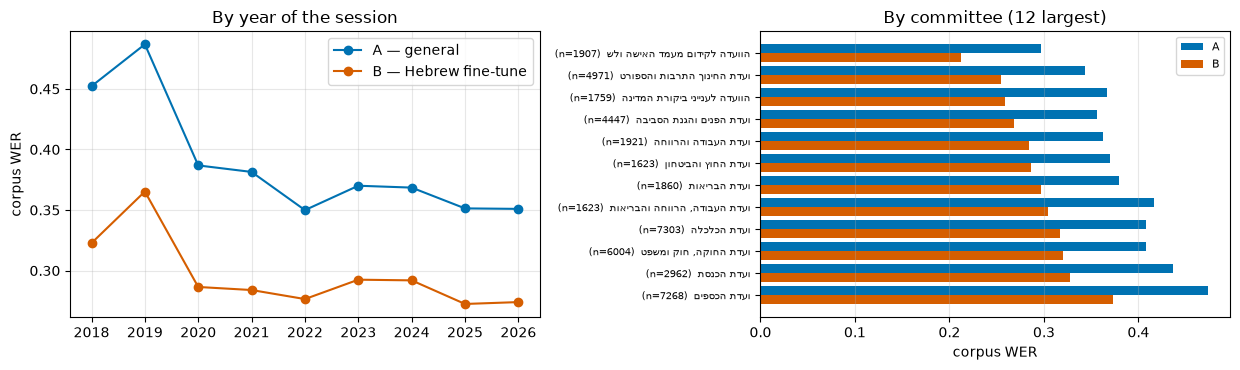

In [12]:
k = X.with_committee(kept)
display(X.by_condition(k, 'year').round(3).T)
display(X.by_condition(k, 'committee_name', top=12).round(3))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
t = X.by_condition(k, 'year'); ax = axes[0]
ax.plot(t.index, t.WER_A, 'o-', color=C_A, label='A — general'); ax.plot(t.index, t.WER_B, 'o-', color=C_B, label='B — Hebrew fine-tune')
ax.set_ylabel('corpus WER'); ax.set_title('By year of the session'); ax.legend(); ax.grid(alpha=0.3)
t = X.by_condition(k, 'committee_name', top=12); ax = axes[1]; y = np.arange(len(t))
ax.barh(y - 0.2, t.WER_A, 0.4, color=C_A, label='A'); ax.barh(y + 0.2, t.WER_B, 0.4, color=C_B, label='B')
ax.set_yticks(y); ax.set_yticklabels([f'{n[:28]}  (n={int(c)})' for n, c in zip(t.index, t.chunks)], fontsize=7.5); ax.invert_yaxis()
ax.set_xlabel('corpus WER'); ax.set_title('By committee (12 largest)'); ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); save('conditions'); plt.show()

**Reading it.** Conditions move WER as much as speakers do: B scores 0.32–0.37 in 2018–19 and 0.27–0.29
from 2020, and 0.21–0.37 across committees. Hence the date-ordered train/test split, and the held-out check on
the panel in §9.

---
## 8. Is the scoring fair to B?

If B's inserted words were hallucinations they would be its own; if the protocol simply left them out, A
would hear them too.

In [13]:
ia = X.insertion_agreement(kept)
print(f"B's inserted words also in A's hypothesis of the same chunk: {ia['share_of_B_insertions_also_in_A']:.0%}  "
      f"(A's in B's: {ia['share_of_A_insertions_also_in_B']:.0%})")

B's inserted words also in A's hypothesis of the same chunk: 73%  (A's in B's: 71%)


> **Withdrawn as evidence (2026-10-03).** The forgiven-shared ("protocol-aware") count below forgives an insertion that the other model also produced, on the reading that two models agreeing against the protocol means the protocol dropped a spoken word. On human-corrected committee clips about half of such shared words were not spoken (`docs/personalization_research.md` § 1.5). The cells are kept as a record; cite the standard count.

So most insertions are speech the protocol omitted. **Forgiven-shared WER** re-scores everything without
charging an inserted word the *other* model also produced; substitutions, deletions and the denominator are
unchanged. The question is whether any conclusion above depends on the scoring.

In [14]:
kf = X.forgiven_counts(kept)
spk_f = E.per_speaker(kf, n_boot=1000, suffix='_f')
rows = {}
for name, f in (('standard', ''), ('forgiven-shared', '_f')):
    c = E.corpus_scores(kf, f); rows[name] = dict(WER_A=c.WER_A, WER_B=c.WER_B, B_removes=(c.WER_A - c.WER_B) / c.WER_A)
display(pd.DataFrame(rows).T.round(3))

rr = spk.reliable
print('speaker ranking, standard vs forgiven (Spearman): ' +
      ', '.join(f'{m} {stats.spearmanr(spk.loc[rr, m], spk_f.loc[rr, m]).statistic:.2f}' for m in ('wer_A', 'wer_B', 'gain_rel')))
print(f'speakers hurt by the fine-tune: standard {(spk[rr].gain_abs < 0).sum()}, forgiven {(spk_f[rr].gain_abs < 0).sum()}')
cand, cand_f = E.candidates(spk), E.candidates(spk_f)
print(f'lowest-gain 40: {len(set(cand.head(40).index) & set(cand_f.head(40).index))} of 40 the same')

totals_f = kf.groupby('speaker_id').agg(werr_A_total=('werr_A_f', 'sum'), werr_B_total=('werr_B_f', 'sum'))
rank_f = E.rank_rules(spk_f.join(totals_f).join(attrs), n_perm=2000)
pd.DataFrame({('gain', 'standard'): rank.separates_gain, ('gain', 'forgiven'): rank_f.separates_gain,
              ('difficulty', 'standard'): rank.separates_wer, ('difficulty', 'forgiven'): rank_f.separates_wer})

,WER_A,WER_B,B_removes
standard,0.387,0.292,0.244
forgiven-shared,0.282,0.179,0.367


speaker ranking, standard vs forgiven (Spearman): wer_A 0.94, wer_B 0.92, gain_rel 0.96
speakers hurt by the fine-tune: standard 0, forgiven 0
lowest-gain 40: 35 of 40 the same


gain          difficulty         
                      standard forgiven   standard forgiven
rule                                                       
age quartile              True     True      False    False
country of origin        False    False      False     True
gender                    True     True       True     True
nationality               True     True      False    False
religion                  True     True      False    False
religious orientation    False    False       True     True
speaking rate tertile     True     True      False    False

**Reading it.** The level and B's advantage change (B removes 24% of A's error → 37%); the conclusions do
not. The speaker ranking holds (rho ≥ 0.92), no one is hurt, 35 of the 40 lowest-gain speakers are the same,
and every grouping keeps its verdict on gain. Standard WER stays the headline; this is the robustness check.

---
## 9. Who to adapt

Personal adaptation has the most room where the generic fine-tune helped least: reliable speakers by lowest
relative gain, with the CI on the gain.

In [15]:
cand = cand.join(attrs[['speaker_name', 'gender', 'rate_band', 'orientation']])
med = r.gain_abs.median()
print(f'{int((cand.gain_abs_hi < med).sum())} speakers whose whole gain CI is below the median gain ({med:.3f})')
cand.head(20)[['speaker_name', 'gender', 'rate_band', 'orientation', 'n_seg', 'wer_A', 'wer_B', 'gain_abs_lo', 'gain_abs_hi', 'gain_rel']].round(3)

70 speakers whose whole gain CI is below the median gain (0.090)


,speaker_name,gender,rate_band,orientation,n_seg,wer_A,wer_B,gain_abs_lo,gain_abs_hi,gain_rel
speaker_id,,,,,,,,,,
12937,אופיר אקוניס,Male,medium speech,Secular,104,0.333,0.298,0.018,0.054,0.106
30788,אביר קארה,Male,fast speech,Unrecorded,294,0.385,0.343,0.028,0.056,0.108
30646,אוסנת הילה מארק,Female,slow speech,Unrecorded,281,0.415,0.370,0.010,0.074,0.110
30877,משה פסל,Male,fast speech,Unrecorded,338,0.343,0.303,0.023,0.058,0.118
30685,אורית פרקש הכהן,Female,medium speech,Unrecorded,261,0.395,0.344,0.038,0.066,0.131
532,יולי יואל אדלשטיין,Male,slow speech,Religious,217,0.377,0.327,0.027,0.068,0.132
30861,שלום דנינו,Male,slow speech,Unrecorded,400,0.342,0.296,0.030,0.063,0.135
30084,רועי פולקמן,Male,fast speech,Unrecorded,343,0.524,0.452,0.059,0.086,0.137
30809,גלית דיסטל אטבריאן,Female,medium speech,Secular,251,0.282,0.242,0.023,0.057,0.140


### The panel

The eleven speakers chosen for Stage 2 (`src/evaluation/outputs/committees_panel.csv`, reasons in
`docs/adaptation_plan.md`): S1 the fine-tune failed them, S2 simply hard, S3 typical but left behind,
S4 headroom, C high-gain controls. `gain pct` is the speaker's percentile of relative gain under each scoring.

In [16]:
panel = pd.read_csv(os.path.join('..', 'src', 'evaluation', 'outputs', 'committees_panel.csv'), index_col=0)
core = panel[~panel.profile.str.contains('alt')]
order = core.sort_values(['profile', 'speaker_name']).index
pct = {k: t[t.reliable].gain_rel.rank(pct=True) for k, t in (('standard', spk), ('forgiven', spk_f))}
view = core.loc[order, ['profile', 'speaker_name']].join(spk.loc[order, ['n_seg', 'wer_A', 'wer_B', 'gain_rel']])
for k in pct: view[f'gain pct {k}'] = pct[k].reindex(order)
view.round(3)

,profile,speaker_name,n_seg,wer_A,wer_B,gain_rel,gain pct standard,gain pct forgiven
speaker_id,,,,,,,,
30752,C,וליד טאהא,262,0.362,0.228,0.372,0.943,0.943
30777,C,משה טור פז,226,0.284,0.198,0.301,0.797,0.716
30701,S1,אופיר כץ,276,0.433,0.345,0.203,0.264,0.253
30685,S1,אורית פרקש הכהן,261,0.395,0.344,0.131,0.019,0.023
30831,S1,אליהו דלל,280,0.383,0.328,0.143,0.050,0.100
23558,S2,דוד ביטן,310,0.524,0.390,0.256,0.594,0.755
30843,S2,יאסר חוג'יראת,219,0.464,0.361,0.222,0.391,0.341
30813,S3,אבתיסאם מראענה,245,0.339,0.287,0.155,0.077,0.034
30868,S3,יונתן מישרקי,306,0.387,0.306,0.209,0.295,0.375


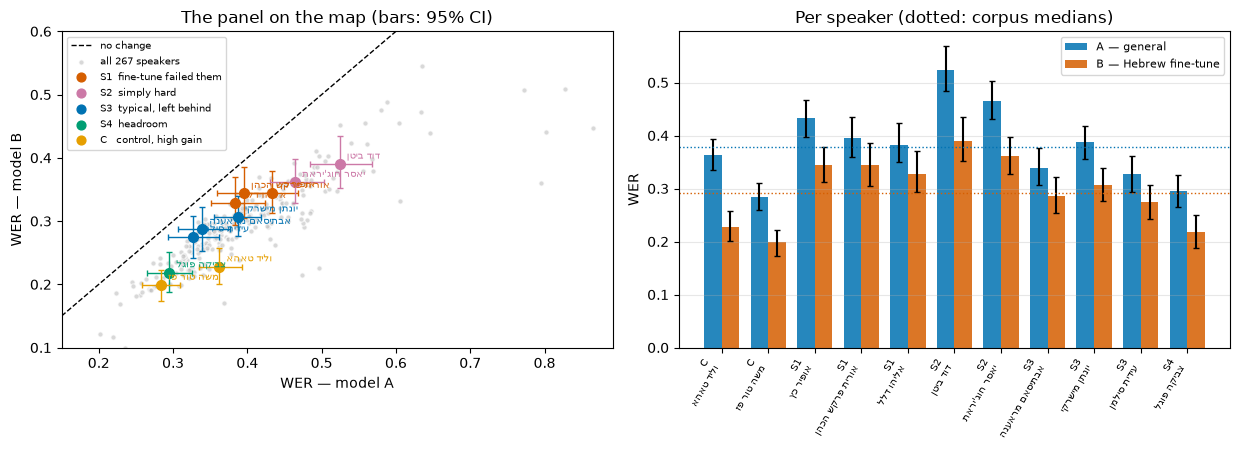

In [17]:
colors = {'S1': '#D55E00', 'S2': '#CC79A7', 'S3': '#0072B2', 'S4': '#009E73', 'C': '#E69F00'}
labels = {'S1': 'S1  fine-tune failed them', 'S2': 'S2  simply hard', 'S3': 'S3  typical, left behind', 'S4': 'S4  headroom', 'C': 'C   control, high gain'}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]; lim = [0.15, spk.wer_A.max() * 1.03]
ax.plot(lim, lim, 'k--', lw=1, label='no change')
ax.scatter(spk.wer_A, spk.wer_B, s=14, color='0.75', alpha=0.6, edgecolor='white', label=f'all {len(spk)} speakers')
for sid, p in core.iterrows():
    s = spk.loc[sid]; c = colors[p.profile]
    ax.errorbar(s.wer_A, s.wer_B, xerr=[[s.wer_A - s.wer_A_lo], [s.wer_A_hi - s.wer_A]], yerr=[[s.wer_B - s.wer_B_lo], [s.wer_B_hi - s.wer_B]], fmt='o', color=c, ms=7, capsize=2, lw=1)
    ax.annotate(p.speaker_name, (s.wer_A, s.wer_B), xytext=(5, 4), textcoords='offset points', fontsize=7.5, color=c)
for k, c in colors.items(): ax.scatter([], [], color=c, s=40, label=labels[k])
ax.set_xlim(lim); ax.set_ylim(0.1, 0.6); ax.set_xlabel('WER — model A'); ax.set_ylabel('WER — model B'); ax.legend(fontsize=7.5, loc='upper left'); ax.set_title('The panel on the map (bars: 95% CI)')
ax = axes[1]; x = np.arange(len(order)); w = 0.38; s = spk.loc[order]
ax.bar(x - w/2, s.wer_A, w, color=C_A, alpha=0.85, label='A — general', yerr=[s.wer_A - s.wer_A_lo, s.wer_A_hi - s.wer_A], capsize=2)
ax.bar(x + w/2, s.wer_B, w, color=C_B, alpha=0.85, label='B — Hebrew fine-tune', yerr=[s.wer_B - s.wer_B_lo, s.wer_B_hi - s.wer_B], capsize=2)
ax.axhline(spk.wer_B.median(), color=C_B, ls=':', lw=1); ax.axhline(spk.wer_A.median(), color=C_A, ls=':', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{core.loc[i, "profile"]}\n{core.loc[i, "speaker_name"]}' for i in order], fontsize=7, rotation=60, ha='right')
ax.set_ylabel('WER'); ax.set_title('Per speaker (dotted: corpus medians)'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); save('panel_map'); plt.show()

**Is each profile stable over time?** WER per session; squares are the latest ~35% of each speaker's words,
held out as personal-test. The ranking used only the earlier sessions, so the held-out ones are an independent
check. A speaker whose two eras disagree has a profile that is partly time, not voice, and should be swapped for
an alternate.

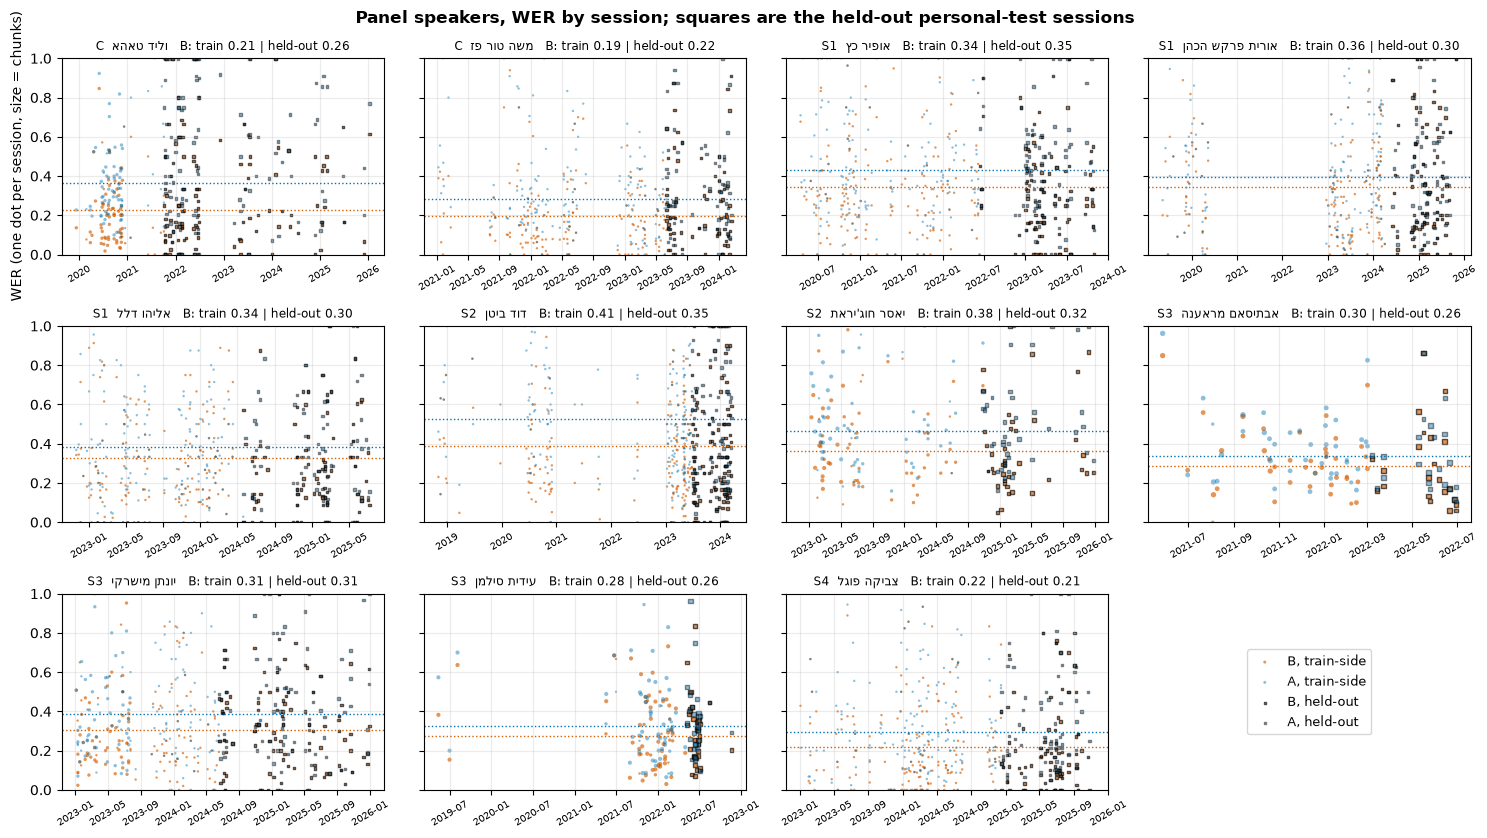

In [18]:
def session_wer(sid):
    d = kept[kept.speaker_id == sid]
    per = d.groupby('session').agg(date=('session_date', 'first'), words=('n_words', 'sum'), eA=('werr_A', 'sum'), eB=('werr_B', 'sum'), chunks=('chunk_id', 'size')).sort_values('date')
    per['wer_A'] = per.eA / per.words; per['wer_B'] = per.eB / per.words
    per['test_side'] = per.words[::-1].cumsum()[::-1] / per.words.sum() <= 0.35
    return per
fig, axes = plt.subplots(3, 4, figsize=(15, 8.5), sharey=True); axes = axes.ravel()
for k, sid in enumerate(order):
    per = session_wer(sid); ax = axes[k]; p = core.loc[sid]; t = pd.to_datetime(per.date); tr, te = per[~per.test_side], per[per.test_side]
    for side, mk, ec, sfx in [(~per.test_side, 'o', 'none', 'train-side'), (per.test_side, 's', 'k', 'held-out')]:
        ax.scatter(t[side], per.wer_B[side], s=per.chunks[side] * 3, color=C_B, alpha=0.65, marker=mk, edgecolor=ec, label=f'B, {sfx}')
        ax.scatter(t[side], per.wer_A[side], s=per.chunks[side] * 3, color=C_A, alpha=0.45, marker=mk, edgecolor=ec, label=f'A, {sfx}')
    ax.axhline(spk.loc[sid, 'wer_B'], color=C_B, lw=1, ls=':'); ax.axhline(spk.loc[sid, 'wer_A'], color=C_A, lw=1, ls=':')
    ax.set_title(f'{p.profile}  {p.speaker_name}   B: train {tr.eB.sum()/tr.words.sum():.2f} | held-out {te.eB.sum()/te.words.sum():.2f}', fontsize=8.5)
    ax.tick_params(axis='x', labelsize=7, rotation=30); ax.set_ylim(0, 1.0); ax.grid(alpha=0.25)
axes[-1].axis('off'); axes[0].set_ylabel('WER (one dot per session, size = chunks)')
h, l = axes[0].get_legend_handles_labels(); axes[-1].legend(h, l, loc='center', fontsize=9)
fig.suptitle('Panel speakers, WER by session; squares are the held-out personal-test sessions', fontsize=12, fontweight='bold')
plt.tight_layout(); save('panel_sessions'); plt.show()

**Reading it.**

* 70 reliable speakers have a gain clearly below the median: the pool Stage 2 can draw from.
* S1 and S3 come from the bottom of that list (2nd–8th percentile; אופיר כץ and יונתן מישרקי near the 30th).
  S2, S4 and C are deliberately not low-gain: they are the contrasts.
* Only דוד ביטן moves under forgiven scoring (59th → 75th percentile): part of his difficulty is the protocol.
* Held-out sessions are mostly a little easier than train-side ones (B: 0.30–0.35 against 0.34–0.37 for S1),
  in line with the drop in WER after 2019. The two controls go the other way (0.21 → 0.26, 0.19 → 0.22), which
  narrows the gap between C and S3 on the test side.

---
## Limits

* **Labels are unverified.** Every number assumes the protocol named the audible speaker (§5); the audio gate has not run.
* **One filter.** Chunks where the protocol condensed the speech (< 50 words/min, 1.3% of chunks) stay in and score WER ≈ 2 under both models.
* **One grouping rule at a time.** No model that controls for one attribute while testing another.
* **Shared insertions are evidence, not proof** (§8). A and B both descend from Whisper large-v3 and may hallucinate alike; a small human verbatim sample would settle it.